# General procedure

Given a target (usually in the central brain), we'd like to estimate its RF. We do so by finding its columnar inputs in ME/LO/LOP and combining the RFs of these inputs. So the first step is to find a "good" set of columnar input neurons. This notebook is about finding these neurons by propogating through the network (using pagerank) and visual inspection.

We want to estimate the RF of a target neuron. We first propogate upstream via the connectivity matrix, determine which columnar cells to use, and optionally visualize the results. Then we compute the RF based on this cell type, using a separate script. 

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
"""
This cell does the initial project setup.
If you start a new script or notebook, make sure to copy & paste this part.

A script with this code uses the location of the `.env` file as the anchor for
the whole project (= PROJECT_ROOT). Afterwards, code inside the `src` directory
are available for import.
"""
from pathlib import Path
import sys
from dotenv import load_dotenv, find_dotenv
# load_dotenv()
PROJECT_ROOT = Path(find_dotenv()).parent
sys.path.append(str(PROJECT_ROOT.joinpath('src')))
print(f"Project root directory: {PROJECT_ROOT}")

Project root directory: c:\Users\zhaoa\HHMI Dropbox\Arthur Zhao\sync_userA\Documents\ReiserGroup\p_ol_connectome\github_ol_analysis


In [3]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import networkx as nx
import pickle 

In [4]:
# from utils import cave_client
# c = cave_client.connect()

In [5]:
# import fafbseg
# import navis
from fafbseg import flywire

# from utils.plotting_functions import plot_pyvis_Angel
from utils.graph_utils import collect_shortest_paths

In [6]:
from utils.config import CACHE_DIR, DATA_DIR, FIG_DIR

# save results if needed
results_dir = FIG_DIR / 'rf'
results_dir.mkdir(parents=True, exist_ok=True)

cache_dir = CACHE_DIR / 'rf'
cache_dir.mkdir(parents=True, exist_ok=True)

Download and save data file to /cache

https://codex.flywire.ai/api/download

In [7]:
# load flywire_783
classification = pd.read_csv(DATA_DIR / 'flywire_783' / 'classification.csv')
el_idtype = pd.read_csv(DATA_DIR / 'flywire_783' / 'connections_id_type.csv')

# visual_neuron_types = pd.read_csv(DATA_DIR / 'flywire_783' / 'visual_neuron_types.csv')

# Example, propagate N=2 hops

## Start with a target neuron / instance

In [8]:
# target = sink
target_type = 'ER4d'
# 'AOTU008_R'
# 'AOTU014'

n_target = flywire.search_annotations("^" + target_type + "$")
print(n_target.shape)

n_target = n_target[n_target['side'] == "right"]
print(n_target.shape)

Using annotation version "latest tagged release" (ebd66db from 2024-07-30) from https://github.com/flyconnectome/flywire_annotations.
Using materialization version 783.
(26, 27)
(14, 27)


In [9]:
# select one cell
id_target = n_target['root_id'].values[1]
# id_target = 720575940628459526

In [10]:
# Generate a URL with these partners
flywire.encode_url(segments= n_target['root_id'].values, open=False)
# flywire.encode_url(segments= id_target, open=False)

'https://ngl.flywire.ai/?json_url=https://globalv1.flywire-daf.com/nglstate/5896191985319936'

In [11]:
# all cells, run for N hops, collect all ids
N = 2
wt_threshold = 5

# id_post = n_target['root_id'].tolist()
id_post = [id_target]
id_upstream = []
for i in range(N):
    n_pre = el_idtype[el_idtype['post_root_id'].isin(id_post)]
    n_pre = n_pre[n_pre['syn_count'] >= wt_threshold]
    id_post = n_pre['pre_root_id'].tolist()
    id_upstream += id_post
    id_upstream = list(set(id_upstream))

len(id_upstream)

286

In [12]:
n_upstream = classification[classification['root_id'].isin(id_upstream)]

# n_upstream[n_upstream['super_class'] == 'optic']['cell_type'].value_counts()
n_upstream[n_upstream['super_class'] == 'visual_projection']['cell_type'].value_counts()

cell_type
MeTu1    19
Name: count, dtype: int64

Here we should examine the result and pick a reasonable number of cell types for furture investigation. Helpful to refer to the OL paper summary plots

ME, as an earlier layer, is preferrable, but need to check possible parallel pathways which might have different RFs.

Best way to check the RF size for unknown types is here: https://reiserlab.github.io/male-drosophila-visual-system-connectome/index.html


In [13]:
#  choose a cell type
id_source = n_upstream[n_upstream['cell_type'] == 'MeTu1']['root_id'].values
# id_source = n_upstream[n_upstream['cell_type'] == 'Mi1']['root_id'].values
id_source

array([720575940607798402, 720575940628319656, 720575940626330353,
       720575940626509673, 720575940616190164, 720575940632772704,
       720575940622647989, 720575940627843594, 720575940644670499,
       720575940623295271, 720575940620785030, 720575940622012326,
       720575940622287228, 720575940628221227, 720575940610257476,
       720575940621434807, 720575940618971227, 720575940609976533,
       720575940616078751], dtype=int64)

# Collect nodes in shortest paths, and their inputs

In [14]:
el = el_idtype[['pre_root_id', 'post_root_id', 'syn_count']]
# change column names
el.columns = ['source', 'target', 'weight']

In [15]:
from utils.graph_utils import collect_shortest_paths

path_len, paths_all = collect_shortest_paths(id_source, id_target, edgelist=el, min_weight=5)

## contributions from candidate celltype

### adj and transition matrix

In [ ]:
# adj = flywire.get_adjacency(sources= None, targets= source_id) # source can not be None
# adj

In [16]:
# collect all unique ids from paths_all
id_path = list(set([item for sublist in paths_all for item in sublist]))

syn_total = el_idtype[el_idtype['post_root_id'].isin(id_path)] \
    .groupby('post_root_id') \
    .agg({'syn_count': 'sum'}) \
    .reindex(id_path) #add missing ids with 0 synapses
    # .reset_index()

In [17]:
# adj and transition matrix
adj = flywire.get_adjacency(sources= id_path, targets= id_path)

# normalize by input
# divide each row in adj by corresponding row in syn_total
adj_norm = adj.div(syn_total.loc[adj.columns.values, 'syn_count'], axis=1)

m = adj_norm.reindex(index=id_path, columns=id_path, fill_value=0)
# replace nan with 0
m = m.fillna(0)
m_adj = m.copy()

# backward-transition matrix, normalized by row 
m_trans = m.copy().T

Using materialization version 783.


### prop matrix

In [19]:
# propagation
from network.prop_by_adj import prop_series, prop_series_inf

trans_inf = prop_series_inf(m_trans)
# trans_long = prop_series(m_trans, 100)

# normalize by max
trans_inf = trans_inf / np.max(trans_inf)

# keep only the ids in id_path
trans_inf = trans_inf.reindex(index=id_path).reindex(columns=id_path)

trans_inf.shape

Project root directory: c:\Users\zhaoa\HHMI Dropbox\Arthur Zhao\sync_userA\Documents\ReiserGroup\p_ol_connectome\github_ol_analysis


c:\Users\zhaoa\HHMI Dropbox\Arthur Zhao\sync_userA\Documents\ReiserGroup\p_ol_connectome\github_ol_analysis\src\network\prop_by_adj.py:49: RuntimeWarning: invalid value encountered in divide
  m_adj = m_adj / m_adj.sum(axis=0)
c:\Users\zhaoa\HHMI Dropbox\Arthur Zhao\sync_userA\Documents\ReiserGroup\p_ol_connectome\github_ol_analysis\src\network\prop_by_adj.py:54: RuntimeWarning: invalid value encountered in divide
  m_trans = m_trans / m_trans.sum(axis=1)[:, np.newaxis]


(21, 21)

### evaluate how much each cell comtributions to the target neuron ?

In [20]:
# initial state with the target as the active node
v0 = [1 if np.isin(trans_inf.index[i], id_target) else 0 for i in range(len(id_path))]
# equliibrium state
contrib = v0 @ trans_inf

# merge neuron_info on the index of contrib
contrib.name = 'contribution'
contrib = pd.merge(contrib, classification[['root_id','cell_type','hemibrain_type', 'side']], left_index=True, right_on='root_id', how='left')

# replace NaN in cell_type with values from hemibrain_type
contrib['cell_type'] = contrib['cell_type'].fillna(contrib['hemibrain_type'])

In [21]:
contrib['contribution'].sum()

0.484987481410114

array([[<Axes: title={'center': 'contribution'}>]], dtype=object)

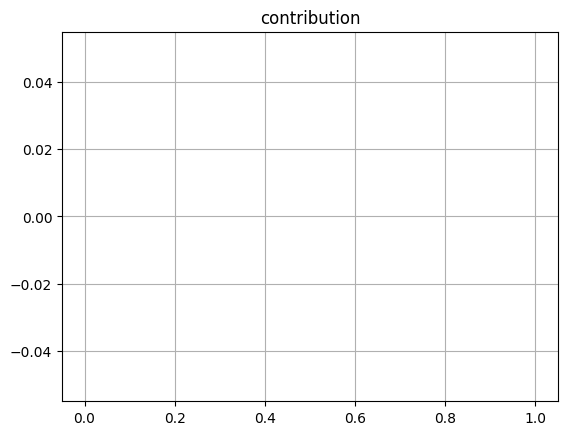

In [22]:
# does all cells contribute by the same amount?
# contrib[contrib['cell_type'].isin(['MeTu1'])].hist('contribution', bins=50)
contrib[contrib['cell_type'].isin(['Mi1'])].hist('contribution', bins=50)

# Visualize network, interactive plot -> this doesn't work right now

In [23]:
g_source = contrib[contrib['root_id'].isin(id_source)]
g_target = contrib[contrib['root_id'].isin([id_target])]
n_path = contrib.copy()

# change column name from root_id to bodyId
g_source = g_source.rename(columns={'root_id': 'bodyId'})
g_target = g_target.rename(columns={'root_id': 'bodyId'})
n_path = n_path.rename(columns={'root_id': 'bodyId', 'cell_type': 'instance'})

In [24]:
# make a df from paths_all, each entry in paths_all get a hop number, from 0 to N
df_paths = pd.DataFrame()
for path in paths_all:
    for hop, bodyId in enumerate(path):
        df = pd.DataFrame({'bodyId': [bodyId], 'layer': [hop]})
        df_paths = pd.concat([df_paths, df], ignore_index=True)

ids_layer = df_paths.groupby('bodyId').agg({'layer':'mean'}).reset_index()

In [ ]:
# draw interactive graph
save_path = str(Path(results_dir, "prop_pagerank.html"))

# cell level, not working for larger graphs
plot_pyvis_Angel(m_adj, trans_inf, g_source, g_target, n_path, ids_layer, save_path=save_path, include_nonprimary_links=False)

# type/instant level, TODO

# for notebook
# webbrowser.open_new_tab(save_path)

# Save the relevant ids to compute RFs using "make_RF.ipynb"

In [25]:
g_source.to_pickle(Path(cache_dir, 'g_source.pkl'))
g_target.to_pickle(Path(cache_dir, 'g_target.pkl'))

### DEBUG


In [ ]:
# # el_idtype.head()
# el = pd.DataFrame(np.array([[1, 2, 10],
#                             [1, 3, 5],
#                             [2, 4, 10],
#                             [4, 5, 10],
#                             [3, 5, 10],
#                             [1, 6, 2],
#                             [6, 5, 5]
#                             ]), columns=['source', 'target', 'weight'])
# source = 1
# target = 5